### Práctica 7:
#**Perceptrón simple vs. multicapa**

Integrantes:


* Aguirre Lanto Victor Manuel
* Gasca Fragoso Pedro
* Guevara Badillo Areli Alejandra
* Montiel Toro Arael de Jesús
* Ramirez Lozano Gael Martin

In [1]:
# Importación de bibliotecas
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.utils import plot_model

import numpy as np
import matplotlib.pyplot as plt

## Datos de prueba simulados

In [2]:
# Genera datos espaciados uniformemente
x = np.linspace(-10, 10, 50)

# Modelo generado a partir de las entradas
y = 2 * x ** 2 + 3 * x + 5 * np.random.normal(0, 4, size = len(x))

print(f"x: {x}\n")
print(f"y: {y}")

x: [-10.          -9.59183673  -9.18367347  -8.7755102   -8.36734694
  -7.95918367  -7.55102041  -7.14285714  -6.73469388  -6.32653061
  -5.91836735  -5.51020408  -5.10204082  -4.69387755  -4.28571429
  -3.87755102  -3.46938776  -3.06122449  -2.65306122  -2.24489796
  -1.83673469  -1.42857143  -1.02040816  -0.6122449   -0.20408163
   0.20408163   0.6122449    1.02040816   1.42857143   1.83673469
   2.24489796   2.65306122   3.06122449   3.46938776   3.87755102
   4.28571429   4.69387755   5.10204082   5.51020408   5.91836735
   6.32653061   6.73469388   7.14285714   7.55102041   7.95918367
   8.36734694   8.7755102    9.18367347   9.59183673  10.        ]

y: [154.81361889 135.57071661 157.67828847  97.52519798 138.88351453
 110.20132264  83.01474673  99.33681698  52.80203986  48.8788037
  56.30650329  34.61787245  14.38820979  30.71252282  30.23093675
  38.37990151  27.06028302   2.89807297  -4.92590193  26.62642035
  21.14228387   0.67671353 -30.07762332 -23.33600256  20.7548743
 -24

### Visualizacion de datos

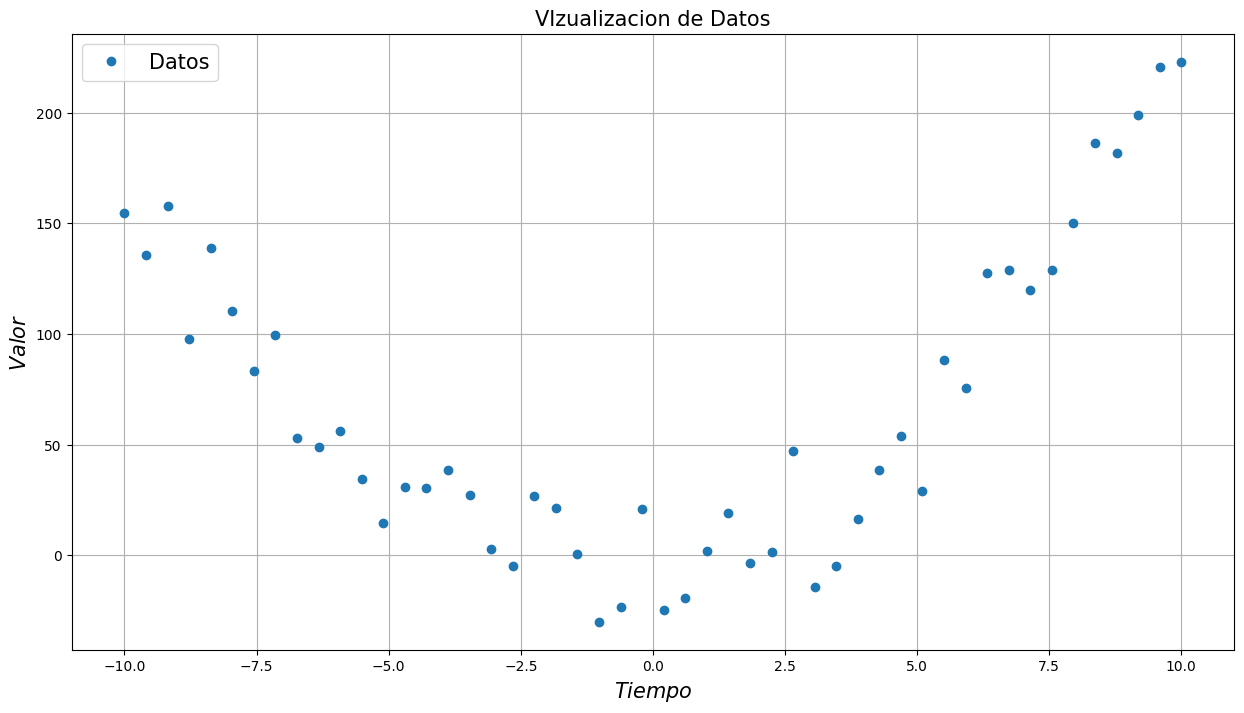

In [3]:
# Generar lienzo
plt.figure(figsize = (15, 8))

#Titulo del lienzo
plt.title("VIzualizacion de Datos", fontsize = 15)

#Dibujar datos
plt.plot(x, y, 'o' )

# Leyenda de Los datos
plt.legend(["Datos"], fontsize=15)

# Nombrar Ejes
plt.xlabel("$Tiempo$", fontsize=15)
plt.ylabel("$Valor$", fontsize=15)

# Poner cuadricula
plt.grid()

# Mostrar imagen
plt.show()

## Construyendo y compilando el perceptrón.

In [4]:
# Creamos un modelo secuencial cuya capa densa tiene una sola neurona unidimensional.
model = keras.Sequential([keras.layers.Dense(units=1, input_shape=(1,))])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# Compilamos el modelo, especificando el optimizador y la función de pérdida.
model.compile(optimizer='sgd', loss='mean_squared_error')

**¿Por qué se eligió esa función de pérdida y ese optimizador para
minimizar dicha pérdida?**

Para la función de pérdida se eligio el `mean_squared_error` (Error Cuadrático Medio) debido a que estamos ante un problema de regresión, donde el objetivo es predecir un valor numérico específico. Mide la distancia entre la predicción del modelo y el valor real, elevando esa diferencia al cuadrado. Esto sirve para que el modelo identifique claramente los errores grandes y se vea forzado a corregirlos, buscando siempre acercarse lo más posible al resultado correcto.

Por otro lado, se selecciono `sgd` (Descenso de Gradiente Estocástico) como el optimizador encargado de reducir esa pérdida. Este algoritmo actúa como el mecanismo de aprendizaje que ajusta paso a paso los parámetros internos de la neurona basándose en el error calculado. Realiza cambios graduales y constantes en los pesos, permitiendo que la red descienda de manera estable hasta encontrar el punto de mínimo error.

In [6]:
# Imprimiendo el resumen del perceptron
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

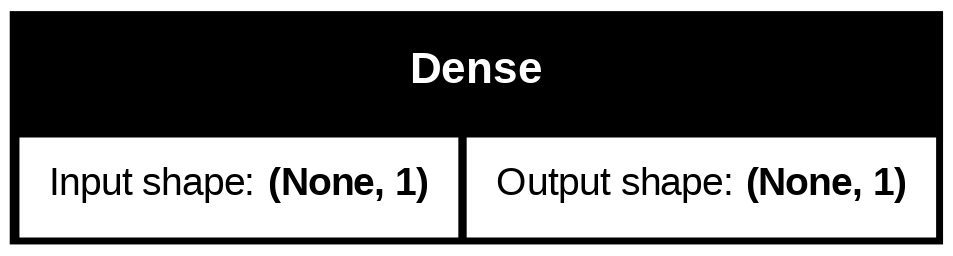

In [7]:
# Visualizacion del modelo en forma de grafo
plot_model(model, show_shapes=True)

### Entrenamiento del perceptron para ajustar datos

In [8]:
model.fit(x, y, epochs=10, verbose=1)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 9839.8457  
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 7529.5415 
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 8550.0029
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 8663.5488
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 8404.4580
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 7138.5342
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 6944.9785
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 7863.6997
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 6210.5132
Epoch 10/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 6613.1782


### Resultados del Perceptron

In [9]:
#Obtener Pesos de La Red
w = model.get_weights();
print(w)

#Imprimir resultados
print("\nObjeto Pesos:",w)
print('\nNumber of Weights -> '+ str(len(w)))
print('\nw =' + str(w[0][0]) +'(Weight)')
print('b ='+ str(w[1])+'("Weight"->Bias)')

[array([[8.6345825]], dtype=float32), array([22.90526], dtype=float32)]

Objeto Pesos: [array([[8.6345825]], dtype=float32), array([22.90526], dtype=float32)]

Number of Weights -> 2

w =[8.6345825](Weight)
b =[22.90526]("Weight"->Bias)


## Predicción de valores dentro de los datos

In [10]:
predecir = model.predict(x)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


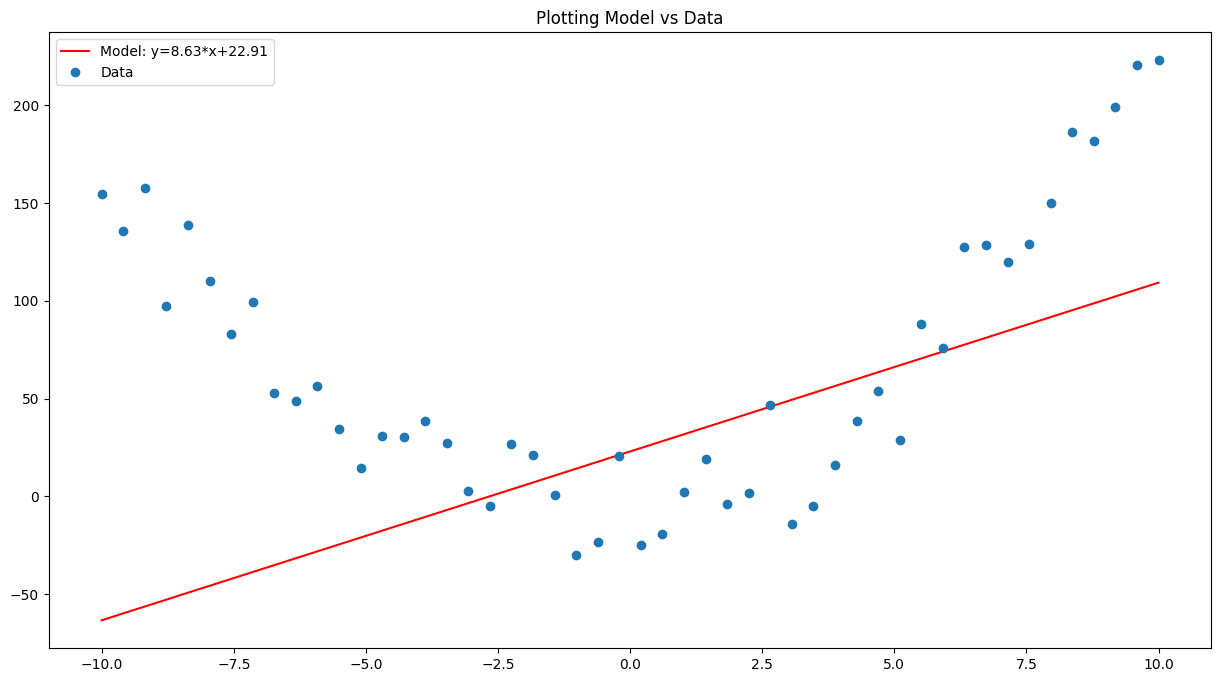

In [12]:
plt.figure(figsize=(15,8))
plt.plot(x, predecir, 'r-', label='Model: y={:.2f}*x+{:.2f}'.format(w[0].item(),w[1].item()))
plt.plot(x, y, 'o', label='Data')
plt.title('Plotting Model vs Data')
plt.legend(loc=0)
plt.show()